**Generative AI Use**: For the purposes of the assignments, the use of generative AI is subject to the same policies regarding collaboration. Just as with other collaborators, each student must write down the solutions independently of the output of the interaction and the submission should include a note denoting the nature of the collaboration. The use of generative AI tools to substantially complete sections of the assignments is not in line with the spirit of the assignments, and would be a violation of the [Honor Code](https://communitystandards.stanford.edu/policies-and-guidance/honor-code).

In [66]:
# This mounts your Google Drive to the Colab VM.
from google.colab import drive
drive.mount('/content/drive')

# TODO: Enter the foldername in your Drive where you have saved the unzipped
# assignment folder, e.g. 'cs231n/assignments/assignment1/'
FOLDERNAME = 'cs231n/assignments/assignment1/'
assert FOLDERNAME is not None, "[!] Enter the foldername."

# Now that we've mounted your Drive, this ensures that
# the Python interpreter of the Colab VM can load
# python files from within it.
import sys
sys.path.append('/content/drive/My Drive/{}'.format(FOLDERNAME))

# This downloads the CIFAR-10 dataset to your Drive
# if it doesn't already exist.
%cd /content/drive/My\ Drive/$FOLDERNAME/cs231n/datasets/
!bash get_datasets.sh
%cd /content/drive/My\ Drive/$FOLDERNAME

#这一段代码是让谷歌硬盘访问代码文件夹

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/My Drive/cs231n/assignments/assignment1/cs231n/datasets
/content/drive/My Drive/cs231n/assignments/assignment1


# k-Nearest Neighbor (kNN) exercise

*Complete and hand in this completed worksheet (including its outputs and any supporting code outside of the worksheet) with your assignment submission. For more details see the [assignments page](http://vision.stanford.edu/teaching/cs231n/assignments.html) on the course website.*

The kNN classifier consists of two stages:

- During training, the classifier takes the training data and simply remembers it
- During testing, kNN classifies every test image by comparing to all training images and transfering the labels of the k most similar training examples
- The value of k is cross-validated

In this exercise you will implement these steps and understand the basic Image Classification pipeline, cross-validation, and gain proficiency in writing efficient, vectorized code.

In [67]:
# Run some setup code for this notebook.

import random
import numpy as np
from cs231n.data_utils import load_CIFAR10
import matplotlib.pyplot as plt

# This is a bit of magic to make matplotlib figures appear inline in the notebook
# rather than in a new window.
%matplotlib inline
plt.rcParams['figure.figsize'] = (10.0, 8.0) # set default size of plots
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

# Some more magic so that the notebook will reload external python modules;
# see http://stackoverflow.com/questions/1907993/autoreload-of-modules-in-ipython
%load_ext autoreload
%autoreload 2

#以上代码都是导入工具函数，属于环境准备

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [68]:
# Load the raw CIFAR-10 data.
cifar10_dir = 'cs231n/datasets/cifar-10-batches-py'

# Cleaning up variables to prevent loading data multiple times (which may cause memory issue)
try:
   del X_train, y_train
   del X_test, y_test
   print('Clear previously loaded data.')
except:
   pass

X_train, y_train, X_test, y_test = load_CIFAR10(cifar10_dir)

# As a sanity check, we print out the size of the training and test data.
print('Training data shape: ', X_train.shape)
print('Training labels shape: ', y_train.shape)
print('Test data shape: ', X_test.shape)
print('Test labels shape: ', y_test.shape)

#以上代码实现数据的加载，以及数据集尺寸的检查
#可以看出，训练集包含50000张三通道图片，测试集包含10000张三通道图片，大小都是32*32

Clear previously loaded data.
Training data shape:  (50000, 32, 32, 3)
Training labels shape:  (50000,)
Test data shape:  (10000, 32, 32, 3)
Test labels shape:  (10000,)


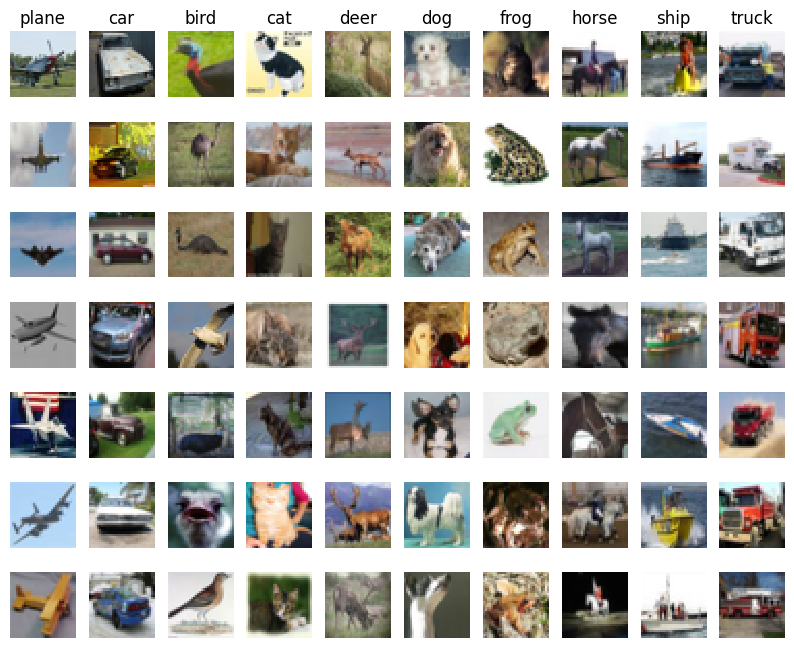

In [69]:
# Visualize some examples from the dataset.
# We show a few examples of training images from each class.
classes = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
num_classes = len(classes)
samples_per_class = 7
#定义名字列表，类别数量，每个类别数量展示几张图片
for y, cls in enumerate(classes):
    #枚举类型，遍历列表同时拿到索引(类别编号y)和值(类别名称)
    #x_train的形状(50000,32,32,3)，图片
    #y_train的形状(50000,),类别
    idxs = np.flatnonzero(y_train == y)
    #这里np.flatnonzero(array)返回一个一维数组
    #包含所有a拍平（按照行优先展开）的非零项的索引
    #具体来说，y_train==y进行一次广播生成数组(50000,)
    #然后进行一次可有可无的拍平，再取出布尔数组中非0值的索引
    #一行代码总共展现了三个步骤
    idxs = np.random.choice(idxs, samples_per_class, replace=False)
    #这里是随机选取samples_per_class个,replace=False表示不重复选取
    #至此得到了训练数据中，每个类别的索引列表idxs

    #对当前类别的每一张随机图片，要计算放在网格的哪里
    #plt的网格坐标从1开始，按照行优先的方法排列
    for i, idx in enumerate(idxs):
        plt_idx = i * num_classes + y + 1
        #计算每个子图的编号，计算结果是
        #第一类:第一张是1号，第二张是1*10+0+1=11号，第三张2*10+0+1=21号
        #这样一来第一类都在第一列
        plt.subplot(samples_per_class, num_classes, plt_idx)
        #绘制一个子图网格，行数7，列数10，第三个参数是当前绘制的子图的索引编号
        #下面的操作都在这个索引编号的子图里面进行
        plt.imshow(X_train[idx].astype('uint8'))
        #取第idx张图片，转为uint8类型显示在这个子图位置上
        plt.axis('off')
        #隐藏坐标轴
        if i == 0:
            plt.title(cls)
        #打印类别名称
plt.show()
#打开窗口

#以上的代码实现的是数据集的“可视化"
#每一类图片都随机抽取7张，一共有10类，把他们排成7行10列，然后展示出来
#目的是大概观察数据集的样子

In [70]:
# Subsample the data for more efficient code execution in this exercise
num_training = 5000
mask = list(range(num_training))
X_train = X_train[mask]
y_train = y_train[mask]
#花式索引
#numpyarray[list]，list是想要取出的位置索引，numpyarray是多维数组
#一维数组作为索引，默认作用于多维数组的第一维，相当于X_train[mask,:,:]
#例子：如果待处理的是二维数组，可以写成array[row_idxs,col_idxs]，用两个一维数组

#具体来说，这里取X_train和y_train这两个数组的前5000个元素，就是一个降采样

num_test = 500
mask = list(range(num_test))
X_test = X_test[mask]
y_test = y_test[mask]
#和刚才一样取了X_test和y_test前500组元素，就是前500组测试数据

# Reshape the image data into rows
X_train = np.reshape(X_train, (X_train.shape[0], -1))
#reshape函数的自动推断占位符，作用就是让函数自动推断这个维度的大小
#具体来说，为了方便计算，我们希望
#新的shape应该是把每张图片都展平成一维数组
#那么第一个维度保留，剩下的维度可以用自动推断，算出应该有多少个元素
X_test = np.reshape(X_test, (X_test.shape[0], -1))
#和上面一样，对测试集进行拍平处理，变成5000个一维数组

print(X_train.shape, X_test.shape)
#验证，应该输出(5000,3072)以及(500,3072)

#以上的代码实现的是数据集的降采样和拍平

(5000, 3072) (500, 3072)


In [71]:
from cs231n.classifiers import KNearestNeighbor

# Create a kNN classifier instance.
# Remember that training a kNN classifier is a noop:
# the Classifier simply remembers the data and does no further processing
classifier = KNearestNeighbor()
classifier.train(X_train, y_train)
#创建一个KNearestNeighbour实例对象
#用train属性记录数据

We would now like to classify the test data with the kNN classifier. Recall that we can break down this process into two steps:

1. First we must compute the distances between all test examples and all train examples.
2. Given these distances, for each test example we find the k nearest examples and have them vote for the label

Lets begin with computing the distance matrix between all training and test examples. For example, if there are **Ntr** training examples and **Nte** test examples, this stage should result in a **Nte x Ntr** matrix where each element (i,j) is the distance between the i-th test and j-th train example.

**Note: For the three distance computations that we require you to implement in this notebook, you may not use the np.linalg.norm() function that numpy provides.**

First, open `cs231n/classifiers/k_nearest_neighbor.py` and implement the function `compute_distances_two_loops` that uses a (very inefficient) double loop over all pairs of (test, train) examples and computes the distance matrix one element at a time.

In [72]:
# Open cs231n/classifiers/k_nearest_neighbor.py and implement
# compute_distances_two_loops.

# Test your implementation:
dists = classifier.compute_distances_two_loops(X_test)
print(dists.shape)

(500, 5000)


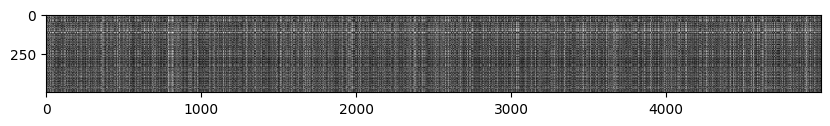

In [73]:
# We can visualize the distance matrix: each row is a single test example and
# its distances to training examples
plt.imshow(dists, interpolation='none')
plt.show()
#这里把距离矩阵展示为一张图片，不插值（避免平滑化数据细节）

**Inline Question 1**

Notice the structured patterns in the distance matrix, where some rows or columns are visibly brighter. (Note that with the default color scheme black indicates low distances while white indicates high distances.)

- What in the data is the cause behind the distinctly bright rows?
- What causes the columns?

$\color{blue}{\textit Your Answer:}$ *行指标代表的是测试数据索引，列指标代表的是训练数据索引。那么，明亮的行表示的是所在行的这个测试样本离所有的训练样本的欧氏距离距离都很远，属于训练集中的离群点。明亮的列表示的是某一个训练样本离所有测试样本的欧氏距离都很远，意味着这个训练样本是训练集中的离群点，本身相对于测试集缺乏代表性或者可能出现损坏。*



In [74]:
# Now implement the function predict_labels and run the code below:
# We use k = 1 (which is Nearest Neighbor).
y_test_pred = classifier.predict_labels(dists, k=1)

# Compute and print the fraction of correctly predicted examples
num_correct = np.sum(y_test_pred == y_test)
accuracy = float(num_correct) / num_test
print('Got %d / %d correct => accuracy: %f' % (num_correct, num_test, accuracy))

Got 137 / 500 correct => accuracy: 0.274000


You should expect to see approximately `27%` accuracy. Now lets try out a larger `k`, say `k = 5`:

In [75]:
y_test_pred = classifier.predict_labels(dists, k=5)
num_correct = np.sum(y_test_pred == y_test)
accuracy = float(num_correct) / num_test
print('Got %d / %d correct => accuracy: %f' % (num_correct, num_test, accuracy))

Got 139 / 500 correct => accuracy: 0.278000


You should expect to see a slightly better performance than with `k = 1`.

**Inline Question 2**

We can also use other distance metrics such as L1 distance.
For pixel values $p_{ij}^{(k)}$ at location $(i,j)$ of some image $I_k$,

the mean $\mu$ across all pixels over all images is $$\mu=\frac{1}{nhw}\sum_{k=1}^n\sum_{i=1}^{h}\sum_{j=1}^{w}p_{ij}^{(k)}$$
And the pixel-wise mean $\mu_{ij}$ across all images is
$$\mu_{ij}=\frac{1}{n}\sum_{k=1}^np_{ij}^{(k)}.$$
The general standard deviation $\sigma$ and pixel-wise standard deviation $\sigma_{ij}$ is defined similarly.

Which of the following preprocessing steps will not change the performance of a Nearest Neighbor classifier that uses L1 distance? Select all that apply. To clarify, both training and test examples are preprocessed in the same way.

1. Subtracting the mean $\mu$ ($\tilde{p}_{ij}^{(k)}=p_{ij}^{(k)}-\mu$.)
2. Subtracting the per pixel mean $\mu_{ij}$  ($\tilde{p}_{ij}^{(k)}=p_{ij}^{(k)}-\mu_{ij}$.)
3. Subtracting the mean $\mu$ and dividing by the standard deviation $\sigma$.
4. Subtracting the pixel-wise mean $\mu_{ij}$ and dividing by the pixel-wise standard deviation $\sigma_{ij}$.
5. Rotating the coordinate axes of the data, which means rotating all the images by the same angle. Empty regions in the image caused by rotation are padded with a same pixel value and no interpolation is performed.

$\color{blue}{\textit Your Answer:}$123


$\color{blue}{\textit Your Explanation:}$
1不会改变分类器表现。所有图片所有像素减去所有图片所有像素总体均值，这对训练集和测试集所有图片所有像素是同一个常数，不影响训练集和测试集之间L1范数下距离的计算。
2也不会改变分类器表现。所有图片所有像素都减去其对应位置的均值，这个数对于训练集和测试集的图片的每个固定位置的像素都是常数，做相同处理之后，不影响训练集和测试集之间L1范数下距离的计算。
3不会改变分类器表现。注意到σ总是正的，且对于训练集、测试集的所有图片，都是同一个常数，所以对一组数同时除σ属于保序操作，因此操作在分类效果上等价于1。
4可能改变分类器表现。不妨和2做对照，这相当于给2计算出的L1范数做了加权和，而权重就等于每个像素位置的标准差，每个像素位置的标准差可能相差很大，这样操作之后，计算出的距离将可能不再保持2中的大小顺序。
5也可能改变分类器表现。旋转一定角度，有可能图片的重要特征被抹去，计算出的L1范数下的距离几乎一定会发生改变，不再保持原来的顺序。

In [76]:
# Now lets speed up distance matrix computation by using partial vectorization
# with one loop. Implement the function compute_distances_one_loop and run the
# code below:
dists_one = classifier.compute_distances_one_loop(X_test)

# To ensure that our vectorized implementation is correct, we make sure that it
# agrees with the naive implementation. There are many ways to decide whether
# two matrices are similar; one of the simplest is the Frobenius norm. In case
# you haven't seen it before, the Frobenius norm of two matrices is the square
# root of the squared sum of differences of all elements; in other words, reshape
# the matrices into vectors and compute the Euclidean distance between them.
difference = np.linalg.norm(dists - dists_one, ord='fro')
print('One loop difference was: %f' % (difference, ))
if difference < 0.001:
    print('Good! The distance matrices are the same')
else:
    print('Uh-oh! The distance matrices are different')

One loop difference was: 0.000000
Good! The distance matrices are the same


In [77]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [78]:
# Now implement the fully vectorized version inside compute_distances_no_loops
# and run the code
dists_two = classifier.compute_distances_no_loops(X_test)

# check that the distance matrix agrees with the one we computed before:
difference = np.linalg.norm(dists - dists_two, ord='fro')
print('No loop difference was: %f' % (difference, ))
if difference < 0.001:
    print('Good! The distance matrices are the same')
else:
    print('Uh-oh! The distance matrices are different')

No loop difference was: 0.000000
Good! The distance matrices are the same


In [79]:
# Let's compare how fast the implementations are
def time_function(f, *args):
    """
    Call a function f with args and return the time (in seconds) that it took to execute.
    """
    import time
    tic = time.time()
    f(*args)
    toc = time.time()
    return toc - tic

two_loop_time = time_function(classifier.compute_distances_two_loops, X_test)
print('Two loop version took %f seconds' % two_loop_time)

one_loop_time = time_function(classifier.compute_distances_one_loop, X_test)
print('One loop version took %f seconds' % one_loop_time)

no_loop_time = time_function(classifier.compute_distances_no_loops, X_test)
print('No loop version took %f seconds' % no_loop_time)

# You should see significantly faster performance with the fully vectorized implementation!

# NOTE: depending on what machine you're using,
# you might not see a speedup when you go from two loops to one loop,
# and might even see a slow-down.

Two loop version took 37.789772 seconds
One loop version took 39.604135 seconds
No loop version took 0.805060 seconds


### Cross-validation

We have implemented the k-Nearest Neighbor classifier but we set the value k = 5 arbitrarily. We will now determine the best value of this hyperparameter with cross-validation.

In [89]:
num_folds = 5
k_choices = [1, 3, 5, 8, 10, 12, 15, 20, 50, 100]

X_train_folds = []
y_train_folds = []
################################################################################
# TODO:
X_train_folds=np.array_split(X_train,num_folds,axis=0)
y_train_folds=np.array_split(y_train,num_folds,axis=0)


# np.array_split(array,number,axis)返回一个新列表，按照axis方向把原数组切成number个元素成列表
                                                  #
# Split up the training data into folds. After splitting, X_train_folds and    #
# y_train_folds should each be lists of length num_folds, where                #
# y_train_folds[i] is the label vector for the points in X_train_folds[i].     #
# Hint: Look up the numpy array_split function.                                #
################################################################################


# A dictionary holding the accuracies for different values of k that we find
# when running cross-validation. After running cross-validation,
# k_to_accuracies[k] should be a list of length num_folds giving the different
# accuracy values that we found when using that value of k.
k_to_accuracies = {}

################################################################################
# TODO:
for chosen_k in k_choices:
  accuracy=0
  k_to_accuracies[chosen_k]=[]
  for i in range(num_folds):
    classifier = KNearestNeighbor()
    train_idxs=[j for j in range(num_folds) if j!=i]

    verify_idx=i
    X_train_new=np.concatenate([X_train_folds[l] for l in train_idxs],axis=0)
    y_train_new=np.concatenate([y_train_folds[l] for l in train_idxs],axis=0)

    X_test_new=X_train_folds[verify_idx]
    classifier.train(X_train_new, y_train_new)
    y_predict=classifier.predict(X_test_new,k=chosen_k)
    accuracy=float(np.sum(y_predict==y_train_folds[verify_idx]))/len(X_test_new)
    k_to_accuracies[chosen_k].append(accuracy)

                                                                   #
# Perform k-fold cross validation to find the best value of k. For each        #
# possible value of k, run the k-nearest-neighbor algorithm num_folds times,   #
# where in each case you use all but one of the folds as training data and the #
# last fold as a validation set. Store the accuracies for all fold and all     #
# values of k in the k_to_accuracies dictionary.                               #
################################################################################


# Print out the computed accuracies
for k in sorted(k_to_accuracies):
    for accuracy in k_to_accuracies[k]:
        print('k = %d, accuracy = %f' % (k, accuracy))

Fold 0: y[:5] = [6 9 9 4 1]
Fold 1: y[:5] = [9 4 3 2 4]
Fold 2: y[:5] = [7 9 9 8 2]
Fold 3: y[:5] = [3 4 5 3 6]
Fold 4: y[:5] = [5 8 5 8 5]

Fold 0: Training set first 10 labels: [9 4 3 2 4 4 1 4 2 2]
Validation set first 10 labels: [6 9 9 4 1 1 2 7 8 3]

Fold 1: Training set first 10 labels: [6 9 9 4 1 1 2 7 8 3]
Validation set first 10 labels: [9 4 3 2 4 4 1 4 2 2]

Fold 2: Training set first 10 labels: [6 9 9 4 1 1 2 7 8 3]
Validation set first 10 labels: [7 9 9 8 2 1 0 2 7 5]

Fold 3: Training set first 10 labels: [6 9 9 4 1 1 2 7 8 3]
Validation set first 10 labels: [3 4 5 3 6 5 9 9 5 1]

Fold 4: Training set first 10 labels: [6 9 9 4 1 1 2 7 8 3]
Validation set first 10 labels: [5 8 5 8 5 9 1 3 2 5]

Fold 0: Training set first 10 labels: [9 4 3 2 4 4 1 4 2 2]
Validation set first 10 labels: [6 9 9 4 1 1 2 7 8 3]

Fold 1: Training set first 10 labels: [6 9 9 4 1 1 2 7 8 3]
Validation set first 10 labels: [9 4 3 2 4 4 1 4 2 2]

Fold 2: Training set first 10 labels: [6 9 9 4 1 1 2 7

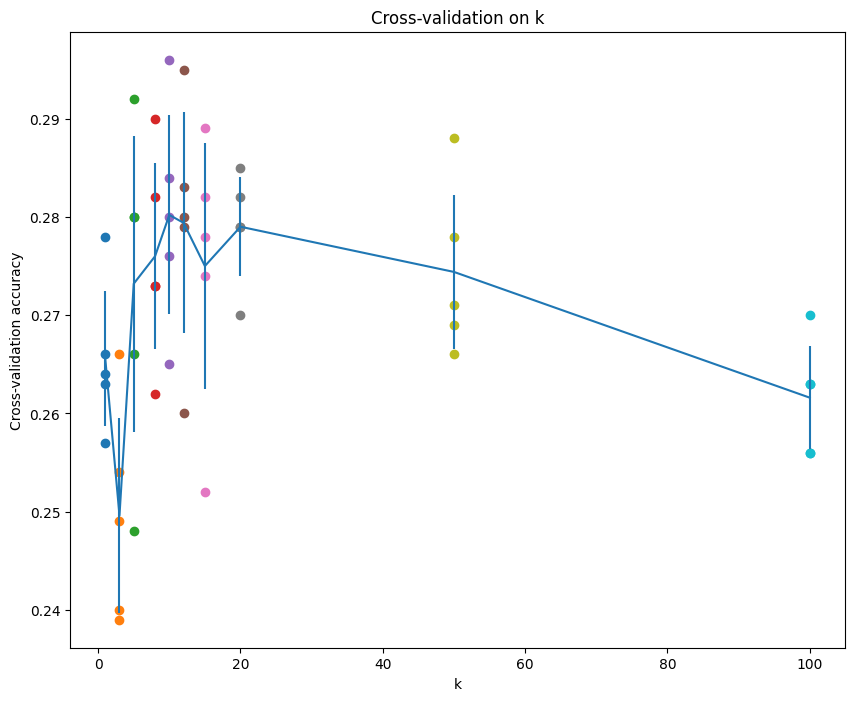

In [90]:
# plot the raw observations
for k in k_choices:
    accuracies = k_to_accuracies[k]
    plt.scatter([k] * len(accuracies), accuracies)

# plot the trend line with error bars that correspond to standard deviation
accuracies_mean = np.array([np.mean(v) for k,v in sorted(k_to_accuracies.items())])
accuracies_std = np.array([np.std(v) for k,v in sorted(k_to_accuracies.items())])
plt.errorbar(k_choices, accuracies_mean, yerr=accuracies_std)
plt.title('Cross-validation on k')
plt.xlabel('k')
plt.ylabel('Cross-validation accuracy')
plt.show()

In [92]:
# Based on the cross-validation results above, choose the best value for k,
# retrain the classifier using all the training data, and test it on the test
# data. You should be able to get above 28% accuracy on the test data.
best_k = 10
classifier = KNearestNeighbor()
classifier.train(X_train, y_train)
y_test_pred = classifier.predict(X_test, k=best_k)

# Compute and display the accuracy
num_correct = np.sum(y_test_pred == y_test)
accuracy = float(num_correct) / num_test
print('Got %d / %d correct => accuracy: %f' % (num_correct, num_test, accuracy))

Got 141 / 500 correct => accuracy: 0.282000


**Inline Question 3**

Which of the following statements about $k$-Nearest Neighbor ($k$-NN) are true in a classification setting, and for all $k$? Select all that apply.
1. The decision boundary of the k-NN classifier is linear.
2. The training error of a 1-NN will always be lower than or equal to that of 5-NN.
3. The test error of a 1-NN will always be lower than that of a 5-NN.
4. The time needed to classify a test example with the k-NN classifier grows with the size of the training set.
5. None of the above.

$\color{blue}{\textit Your Answer:}$24


$\color{blue}{\textit Your Explanation:}$1.不对，kNN的决策边界不是直线，因为kNN的分类空间的划分方式是根据和每个训练数据的相似度决定的，空间被每个训练点划分为一个个Voronoi单元。 2.对，因为1-NN可以直接把训练集输出出来，没有误差，可以完全拟合。5-NN即便是在训练集上，也有可能会出现失误。3.不对，具体表现和训练集、测试集数据都有关，并且一般来说，5-NN的泛化能力更好，稳定性更高，1-NN容易受到干扰。4.对，训练集合越大，测试耗时越多，因为测试样本要和训练集直接比对。5.不对，因为24对。
